# Classification

Classification is a problem of predicting whether something is one thing or another.

- binary classification (is it 1 or 0?)
- multi-class classification (more than 2 things - one label to each)
- multi-label classification (what tags should this object have?)

9:11:00 - https://www.youtube.com/watch?v=Z_ikDlimN6A

### 1. Make classification data and get it ready

In [1]:
from sklearn.datasets import make_circles

# make 1000 samples
n_samples = 1000

# create circles
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

len(X), len(y)

(1000, 1000)

In [2]:
print(f"First 5 samples from X: {X[:5]}")
print(f"First 5 samples from y: {y[:5]}")

First 5 samples from X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples from y: [1 1 1 1 0]


In [3]:
# 2 features of X has one label: 0 or 1
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [4]:
# make dataframe of circle data
import pandas as pd

circles = pd.DataFrame({
    "X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles[:10]

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


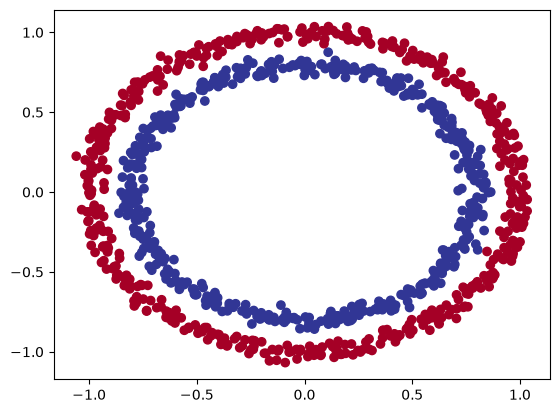

In [5]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.colormaps.get_cmap('RdYlBu'))

In [6]:
# we should understand the problem, so - visualize!

### 1.1 Check input and output shapes

In [7]:
X.shape, y.shape
# X has 2 features, y has no features = it's a single number, a scalar

((1000, 2), (1000,))

In [8]:
X[:5]

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343]])

### 1.2 Turn data into tensors and create train and test splits

In [9]:
import torch

torch.__version__

'2.13.0+cu132'

In [10]:
X2 = torch.from_numpy(X).float()
y2 = torch.from_numpy(y).float()

X2.dtype, X2.shape, y2.dtype, y2.shape,

(torch.float32, torch.Size([1000, 2]), torch.float32, torch.Size([1000]))

In [11]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [12]:
X2[:5], y2[:5], type(X2)

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]),
 torch.Tensor)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [14]:
n_samples, len(X_train), len(X_test), len(y_train), len(y_test)

(1000, 800, 200, 800, 200)

### 2. Building a model

Let's build a model to classify the blue and red dots.

To do so, we need to:
- setup device agnostic code (use GPU)
- construct a model (nn.Module)
- define a loss function and optimizer
- create a training and test loop

In [15]:
import torch
from torch import nn

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [16]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # we need to define a NN which can handle your input layers
        # create 2 Linear layers that are capable of handling the shapes of our data
        # out_feature = 1, because y_train has just 1 number (out_feature = same shape as y)
        # and we want to map X to y
        # but the trick here: add 5 hidden neurons (a hidden layer),
        # takes in 2 features and upscales to 5 features
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))
        # x -> layer_1 -> layer_2 -> output


model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
y_train[0]

tensor(1.)

In [18]:
X_train[0]

tensor([ 0.6579, -0.4651])

In [19]:
device

device(type='cuda')

In [20]:
next(model_0.parameters()).device

device(type='cuda', index=0)